In [1]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
API_KEY = "6a048b0974294f58c8eaf745b08452304a1e227c"
url = f"https://api.census.gov/data/2024/acs/acs1?get=NAME,group(B01001)&for=us:1"

In [4]:
response = requests.get(url)

In [5]:
data = response.json()

In [6]:
df =  pd.DataFrame(data[1:], columns=data[0])

In [7]:
df.head()

,NAME,B01001_001E,B01001_001EA,B01001_001M,B01001_001MA,B01001_002E,B01001_002EA,B01001_002M,B01001_002MA,B01001_003E,...,B01001_048EA,B01001_048M,B01001_048MA,B01001_049E,B01001_049EA,B01001_049M,B01001_049MA,GEO_ID,NAME,us
0,United States,340110990,None,-555555555,*****,168294343,None,32107,None,9370856,...,None,29592,None,3974596,None,25125,None,0100000US,United States,1


#Census variable codes for your selected variables
B01001_001E — Total population  
B01001_002E — Total male population  

Young adult male ages:
B01001_009E — Male: 21 years
B01001_010E — Male: 22–24 years
B01001_011E — Male: 25–29 years

Research Question: What proportion of the U.S. population consists of young adult males ages 21–29?


In [ ]:
#Modify your API requests to pull those variables
import requests
import pandas as pd

url = "https://api.census.gov/data/2024/acs/acs1"

params = {
    "get": "NAME,B01001_001E,B01001_002E,B01001_009E,B01001_010E,B01001_011E",
    "for": "us:1"
}

data = requests.get(url, params=params).json()
df = pd.DataFrame(data[1:], columns=data[0])

df

,NAME,B01001_001E,B01001_002E,B01001_009E,B01001_010E,B01001_011E,us
0,United States,340110990,168294343,2251912,6863355,11310221,1


In [9]:
#Clean the data as needed
for col in df.columns:
    if col != "NAME":
        df[col] = pd.to_numeric(df[col])

df

,NAME,B01001_001E,B01001_002E,B01001_009E,B01001_010E,B01001_011E,us
0,United States,340110990,168294343,2251912,6863355,11310221,1


In [11]:
# total young adult males
df["male_21_29"] = (
    df["B01001_009E"] +
    df["B01001_010E"] +
    df["B01001_011E"]
)

# percent of total population
df["pct_of_population"] = df["male_21_29"] / df["B01001_001E"] * 100

# percent of male population
df["pct_of_males"] = df["male_21_29"] / df["B01001_002E"] * 100

df[["NAME","male_21_29","pct_of_population","pct_of_males"]]

,NAME,male_21_29,pct_of_population,pct_of_males
0,United States,20425488,6.005536,12.136764


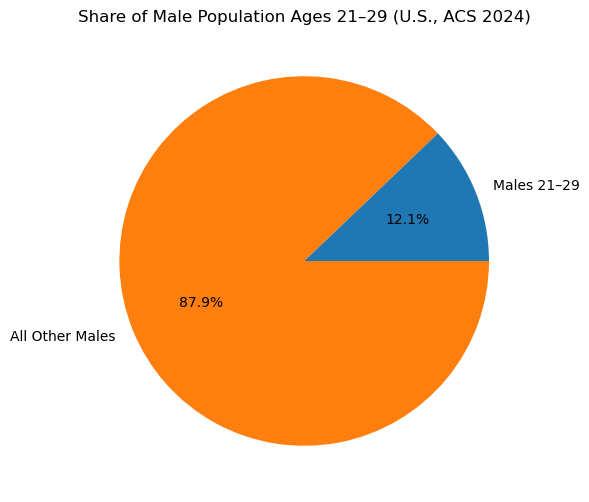

In [13]:
import matplotlib.pyplot as plt

young = df["male_21_29"][0]
other_males = df["B01001_002E"][0] - young

plt.figure(figsize=(6,6))
plt.pie(
    [young, other_males],
    labels=["Males 21–29", "All Other Males"],
    autopct="%1.1f%%"
)

plt.title("Share of Male Population Ages 21–29 (U.S., ACS 2024)")
plt.show()